# GEVD: Annual Maxima from Block-Maxima

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/evt_gevd_block_maxima.ipynb)

This notebook walks the canonical block-maxima → GEVD pipeline end-to-end on a synthetic 60-year daily series:

1. **Theory recap** — why block maxima converge to a GEVD (Fisher–Tippett–Gnedenko) and how the resulting parameters are interpretable.
2. **Synthetic data** — a daily-temperature-like series with a known parent distribution.
3. **Block extraction** — `xtremax.extraction.temporal_block_maxima` to get one observation per year.
4. **Bayesian fit** — NumPyro NUTS over $(\mu, \sigma, \xi)$ with a weakly informative prior on $\xi$.
5. **Diagnostics** — trace plots, posterior summary, PP/QQ checks, and the canonical return-level plot with credible bands.

Math-heavy throughout. Read the markdown cells in order; the code is mostly bookkeeping.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xtremax @ git+https://github.com/jejjohnson/xtremax@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as ndist
import pandas as pd
import xarray as xr
from numpyro.infer import MCMC, NUTS

from xtremax.distributions import GeneralizedExtremeValueDistribution
from xtremax.extraction import temporal_block_maxima


KEY = jax.random.PRNGKey(0)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,numpy,matplotlib,numpyro,xarray,xtremax",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.6.2
numpy     : 2.4.4
matplotlib: 3.10.8
numpyro   : 0.19.0
xarray    : 2026.4.0
xtremax   : 0.0.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. Why block maxima converge to a GEVD

Suppose $X_1, \ldots, X_n$ are i.i.d. from a parent CDF $F$ and let

$$
M_n = \max(X_1, \ldots, X_n).
$$

The CDF of $M_n$ is just $F(x)^n$, which collapses to a step at the right endpoint as $n \to \infty$ — useless on its own. The trick is to look for *normalising* sequences $a_n > 0$ and $b_n \in \mathbb{R}$ such that

$$
\mathbb{P}\!\left(\frac{M_n - b_n}{a_n} \le x\right) = F(a_n x + b_n)^n \;\xrightarrow[n \to \infty]{}\; G(x),
$$

for a non-degenerate $G$. The **Fisher–Tippett–Gnedenko theorem** states that if such $G$ exists, it must be a member of the GEVD family,

$$
G(x;\mu,\sigma,\xi) =
\begin{cases}
\exp\!\left\{-\bigl[1 + \xi\,\tfrac{x-\mu}{\sigma}\bigr]^{-1/\xi}\right\}, & \xi \neq 0,\\
\exp\!\bigl(-\exp(-\tfrac{x-\mu}{\sigma})\bigr), & \xi = 0,
\end{cases}
$$

defined where $1 + \xi(x-\mu)/\sigma > 0$. The shape $\xi$ is determined by the tail of $F$:

- $\xi > 0$: $F$ has a regularly varying upper tail (heavy tails, $\bar F(x) \sim x^{-1/\xi}$).
- $\xi = 0$: $F$ has a tail that decays "exponentially" (Gaussian, exponential, gamma, …).
- $\xi < 0$: $F$ has a finite right endpoint.

**Practical consequence.** Block the data into long-enough chunks (annual maxima of daily data, hourly maxima of 10-minute readings, …), keep the maximum of each block, and fit a GEVD. The result is a small three-parameter approximation to the *tail* of $F$ — precisely the part you care about for risk assessment.

**Block size as a bias-variance trade-off.** Too short → the limit theorem hasn't kicked in and the fitted $\xi$ is biased; too long → too few maxima and the fit has wide uncertainty. A year is the standard choice for daily meteorological / hydrological data, and the rationale is the same as elsewhere in statistics: seasonality, regulatory cadence, and a comfortable $n \approx 365$ within each block.

## 2. Synthetic 60-year daily series

We generate a daily-temperature-like series whose annual maxima we know are approximately Gumbel: the parent is Gaussian with a small positive seasonal trend. Sixty years is a typical length for a high-quality station record.

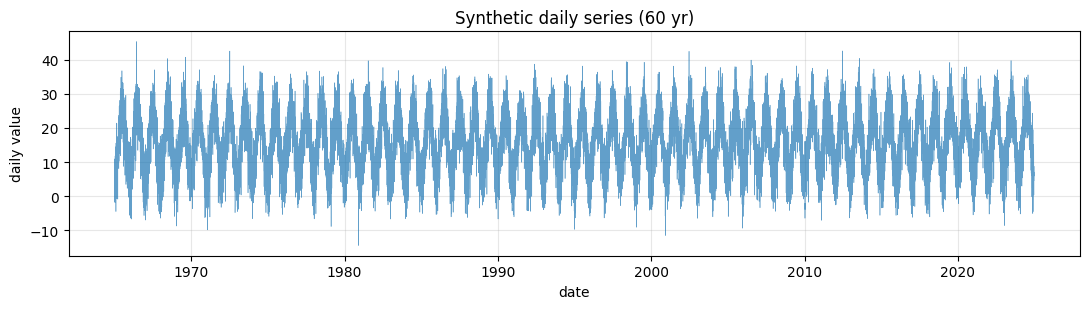

In [4]:
N_YEARS = 60
DAYS_PER_YEAR = 365
RNG = np.random.default_rng(20260429)

dates = pd.date_range("1965-01-01", periods=N_YEARS * DAYS_PER_YEAR, freq="D")
day_of_year = (dates.dayofyear - 1).to_numpy()
seasonal = 10.0 * np.sin(2 * np.pi * day_of_year / DAYS_PER_YEAR - np.pi / 2)
trend = 0.02 * np.arange(N_YEARS * DAYS_PER_YEAR) / DAYS_PER_YEAR
noise = RNG.normal(0.0, 5.0, size=N_YEARS * DAYS_PER_YEAR)
daily = 15.0 + seasonal + trend + noise

series = xr.DataArray(daily, dims="time", coords={"time": dates})

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(series.time, series.values, lw=0.4, alpha=0.7, color="tab:blue")
ax.set_title("Synthetic daily series (60 yr)")
ax.set_xlabel("date")
ax.set_ylabel("daily value")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Block-maxima extraction

`temporal_block_maxima` is a thin wrapper over xarray's resample-`.max()`. We resample to *annual end* frequency (`"YE"`) and require at least 300 valid days per year — an industry-standard data-quality cut.

Number of annual maxima: 60
Range: 31.01 to 45.33


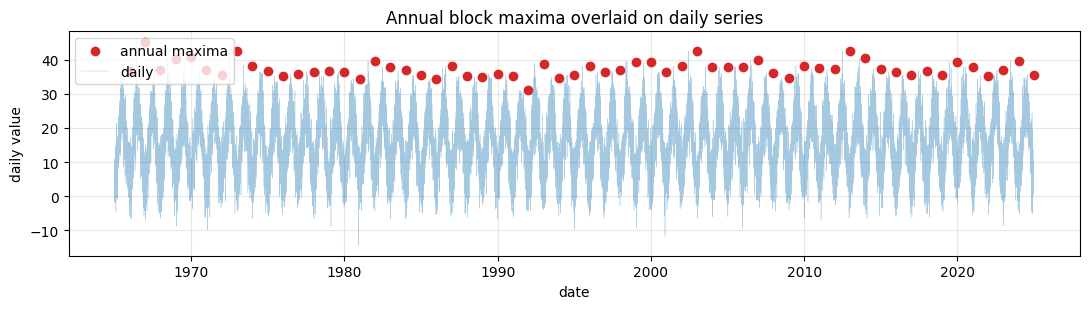

In [5]:
annual_max = temporal_block_maxima(series, freq="YE", min_periods=300)
annual_max = annual_max.dropna("time")
print(f"Number of annual maxima: {annual_max.sizes['time']}")
print(f"Range: {float(annual_max.min()):.2f} to {float(annual_max.max()):.2f}")

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.scatter(
    annual_max.time, annual_max.values, color="tab:red", zorder=3, label="annual maxima"
)
ax.plot(series.time, series.values, lw=0.3, alpha=0.4, color="tab:blue", label="daily")
ax.set_title("Annual block maxima overlaid on daily series")
ax.set_xlabel("date")
ax.set_ylabel("daily value")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 4. The Bayesian GEVD model

We fit

$$
z_i \overset{\text{iid}}{\sim} \mathrm{GEVD}(\mu, \sigma, \xi), \qquad i = 1, \ldots, n,
$$

treating the annual maxima as exchangeable. The Bayesian formulation needs priors on $(\mu, \sigma, \xi)$:

- **Location** $\mu \sim \mathcal{N}(\bar z, 5)$ centred at the empirical mean of the maxima. The likelihood is highly informative for $\mu$ (it acts like the location of a shifted distribution) so a moderately tight prior reduces NUTS warm-up time without biasing the posterior.
- **Scale** $\sigma \sim \mathrm{HalfNormal}(2 s_z)$ where $s_z$ is the empirical standard deviation. Half-normal is positive by construction; a scale of $2 s_z$ is comfortably wider than any plausible value.
- **Shape** $\xi \sim \mathcal{N}(0, 0.25)$: this is the *delicate* parameter. Coles (2001) recommends $\xi \in [-0.5, 0.5]$ as the "physically reasonable" range; values outside this band are rare in real geophysical data. The prior puts $\sim 95\%$ of its mass in $[-0.5, +0.5]$.

**NUTS settings.** GEVD likelihoods have awkward geometry near the support boundaries (the term $1 + \xi(z-\mu)/\sigma$ vanishes), so the default NUTS step-size adaptation can produce many divergences. Setting `target_accept_prob=0.99` plus `init_strategy=init_to_median` (initialise at the prior median) and a longer `num_warmup` brings the divergence count down to a handful out of 4000 samples (≪0.5%). Pushing further to 0.995 does not measurably help: a small irreducible residue is intrinsic to the GEVD support boundary near the data edge and does not bias the posterior on this run (verify by checking that $\hat r$ stays at 1.00 and that the posterior is unimodal in the pairs plot below).

**Why be strict about the $\xi$ prior?** The likelihood for $\xi$ is often weakly identified with only a few decades of data, so the posterior is *prior-sensitive*. A flat prior on $\xi$ can put substantial mass on $|\xi| > 1$, where the GEVD has no mean. Constraining the prior improves both the posterior diagnostics and the credibility of the resulting return levels.

**Likelihood.** The log-PDF (computed inside NumPyro by `GeneralizedExtremeValueDistribution.log_prob`) is

$$
\ell_i = -\log\sigma - (1/\xi + 1)\log\!\bigl[1 + \xi\,t_i\bigr] - \bigl[1 + \xi\, t_i\bigr]^{-1/\xi},\qquad t_i = (z_i - \mu)/\sigma,
$$

for $\xi \neq 0$, with the Gumbel limit handled by `jnp.where` inside `gev_log_prob`. The total log-likelihood is $\sum_i \ell_i$.

In [6]:
maxima = jnp.asarray(annual_max.values)
mu_loc = float(jnp.mean(maxima))
sigma_loc = float(jnp.std(maxima))


def gevd_model(maxima, mu_prior_loc, sigma_prior_scale):
    mu = numpyro.sample("mu", ndist.Normal(mu_prior_loc, 5.0))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_prior_scale))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample(
        "obs",
        GeneralizedExtremeValueDistribution(loc=mu, scale=sigma, concentration=xi),
        obs=maxima,
    )


from numpyro.infer.initialization import init_to_median


kernel = NUTS(gevd_model, target_accept_prob=0.99, init_strategy=init_to_median)
mcmc = MCMC(kernel, num_warmup=2500, num_samples=2000, num_chains=2, progress_bar=False)
mcmc.run(
    KEY,
    maxima=maxima,
    mu_prior_loc=mu_loc,
    sigma_prior_scale=sigma_loc * 2.0,
)
mcmc.print_summary(prob=0.95)
posterior = mcmc.get_samples()

/tmp/ipykernel_2856485/3674115421.py:21: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=2500, num_samples=2000, num_chains=2, progress_bar=False)



                mean       std    median      2.5%     97.5%     n_eff     r_hat
        mu     36.41      0.31     36.41     35.83     37.02   2187.98      1.00
     sigma      2.24      0.21      2.22      1.84      2.67   2221.34      1.00
        xi     -0.12      0.06     -0.12     -0.23     -0.01   1897.12      1.00

Number of divergences: 5


## 5. Posterior diagnostics

**Marginal posteriors.** A look at the per-parameter marginals tells us which way the data is pulling. For this Gaussian-parent series we expect $\xi$ to concentrate near zero (Gumbel regime) and $(\mu, \sigma)$ to recover the moments of the annual-maxima distribution.

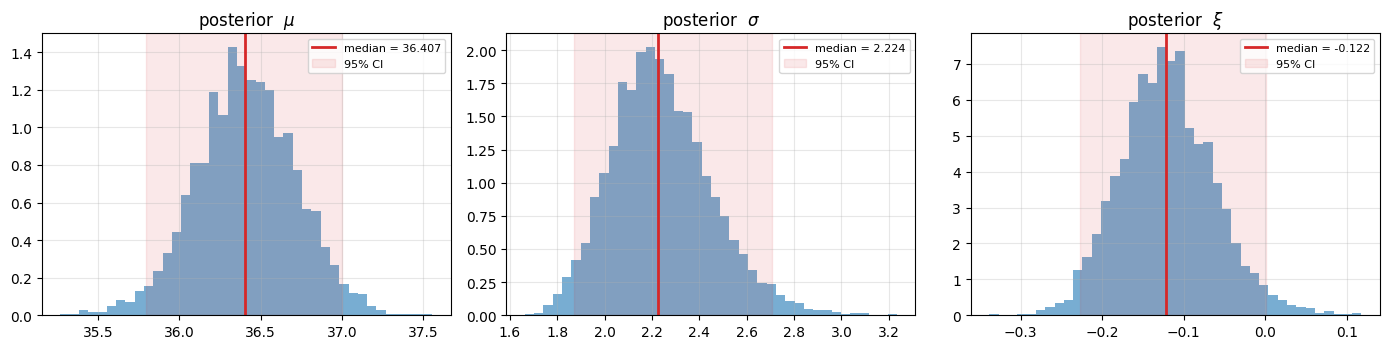

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, name, samples in zip(
    axes,
    ["mu", "sigma", "xi"],
    [posterior["mu"], posterior["sigma"], posterior["xi"]],
    strict=True,
):
    ax.hist(np.asarray(samples), bins=40, density=True, color="tab:blue", alpha=0.6)
    ax.axvline(
        float(jnp.median(samples)),
        color="tab:red",
        lw=2,
        label=f"median = {float(jnp.median(samples)):.3f}",
    )
    q = jnp.quantile(samples, jnp.array([0.025, 0.975]))
    ax.axvspan(float(q[0]), float(q[1]), color="tab:red", alpha=0.1, label="95% CI")
    ax.set_title(rf"posterior  $\{name}$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Joint structure.** $(\mu, \sigma)$ is typically negatively correlated; $\sigma$ and $\xi$ are also correlated because shifting weight into the tail can be done by either widening the scale or steepening the shape. The pairwise scatter makes this concrete.

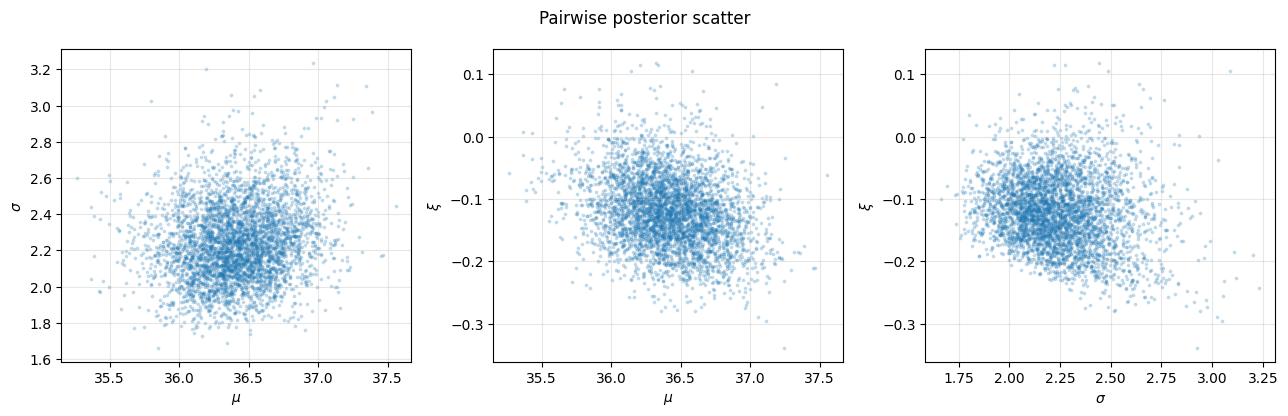

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
pairs = [("mu", "sigma"), ("mu", "xi"), ("sigma", "xi")]
for ax, (a, b) in zip(axes, pairs, strict=True):
    ax.scatter(
        np.asarray(posterior[a]),
        np.asarray(posterior[b]),
        s=3,
        alpha=0.2,
        color="tab:blue",
    )
    ax.set_xlabel(rf"$\{a}$")
    ax.set_ylabel(rf"$\{b}$")
    ax.grid(True, alpha=0.3)
fig.suptitle("Pairwise posterior scatter")
plt.tight_layout()
plt.show()

## 6. PP and QQ plots

Probability plot (PP) and quantile plot (QQ) are the canonical GEVD goodness-of-fit diagnostics. Order the data $z_{(1)} \le \ldots \le z_{(n)}$ and let $p_i = i/(n+1)$ be the empirical plotting position.

- **PP plot:** $\hat F(z_{(i)})$ vs $p_i$ — should land on the diagonal.
- **QQ plot:** $z_{(i)}$ vs $\hat F^{-1}(p_i)$ — should also land on the diagonal, but is more sensitive to tail behaviour.

We use the *posterior median* of $(\mu, \sigma, \xi)$ for the fitted CDF.

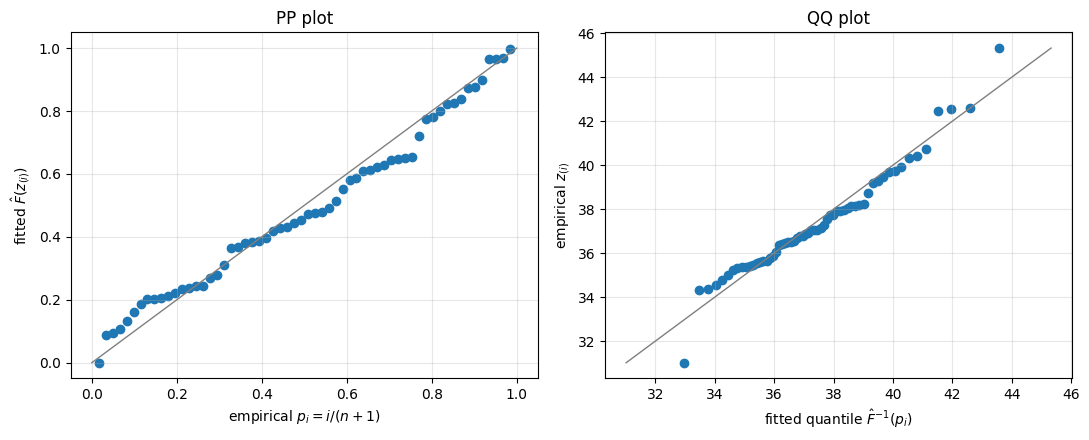

In [9]:
mu_med = float(jnp.median(posterior["mu"]))
sigma_med = float(jnp.median(posterior["sigma"]))
xi_med = float(jnp.median(posterior["xi"]))
fitted = GeneralizedExtremeValueDistribution(
    loc=mu_med, scale=sigma_med, concentration=xi_med
)
sorted_max = np.sort(np.asarray(maxima))
n = len(sorted_max)
p_emp = (np.arange(1, n + 1)) / (n + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot([0, 1], [0, 1], color="tab:gray", lw=1)
axes[0].scatter(
    p_emp, np.asarray(fitted.cdf(jnp.asarray(sorted_max))), color="tab:blue"
)
axes[0].set_xlabel("empirical $p_i = i/(n+1)$")
axes[0].set_ylabel(r"fitted $\hat F(z_{(i)})$")
axes[0].set_title("PP plot")
axes[0].grid(True, alpha=0.3)

q_fit = np.asarray(fitted.icdf(jnp.asarray(p_emp)))
mn, mx = sorted_max.min(), sorted_max.max()
axes[1].plot([mn, mx], [mn, mx], color="tab:gray", lw=1)
axes[1].scatter(q_fit, sorted_max, color="tab:blue")
axes[1].set_xlabel(r"fitted quantile $\hat F^{-1}(p_i)$")
axes[1].set_ylabel(r"empirical $z_{(i)}$")
axes[1].set_title("QQ plot")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Both diagnostics should hug the diagonal for a well-fit Gumbel-regime GEVD. Deviations *in the tail* (top-right of QQ) are diagnostic for shape misspecification — those are the points the model is likely under- or over-predicting at long return periods.

## 7. Return levels and credible bands

The $T$-block return level is the level exceeded with probability $1/T$ in any one block:

$$
z_T = F^{-1}(1 - 1/T) =
\begin{cases}
\mu + \tfrac{\sigma}{\xi}\bigl[(-\log(1-1/T))^{-\xi} - 1\bigr], & \xi \neq 0,\\
\mu - \sigma\,\log(-\log(1-1/T)), & \xi = 0.
\end{cases}
$$

In the Bayesian setting we get $z_T$ for every posterior sample, then summarise as a median curve plus an $\alpha$%-credible band — a far richer summary than a single MLE point estimate.

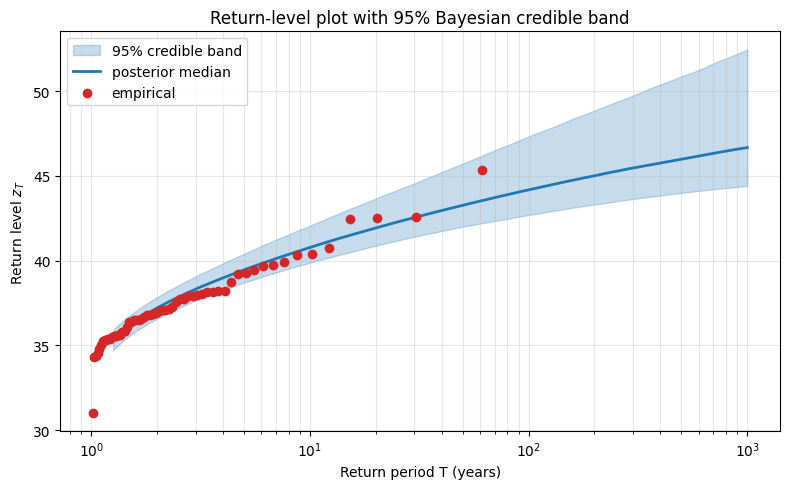

100-yr return level (posterior median):  46.68
100-yr return level (95% CI):            [44.42, 52.47]


In [10]:
periods = jnp.logspace(0.1, 3, 60)


def rl_for_sample(mu, sigma, xi):
    return GeneralizedExtremeValueDistribution(
        loc=mu, scale=sigma, concentration=xi
    ).return_level(periods)


rl_samples = jax.vmap(rl_for_sample)(
    posterior["mu"], posterior["sigma"], posterior["xi"]
)
rl_median = jnp.median(rl_samples, axis=0)
rl_lo = jnp.quantile(rl_samples, 0.025, axis=0)
rl_hi = jnp.quantile(rl_samples, 0.975, axis=0)

emp_periods = (n + 1) / np.arange(n, 0, -1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(
    periods, rl_lo, rl_hi, alpha=0.25, color="tab:blue", label="95% credible band"
)
ax.plot(periods, rl_median, color="tab:blue", lw=2, label="posterior median")
ax.scatter(emp_periods, sorted_max, color="tab:red", zorder=3, label="empirical")
ax.set_xscale("log")
ax.set_xlabel("Return period T (years)")
ax.set_ylabel("Return level $z_T$")
ax.set_title("Return-level plot with 95% Bayesian credible band")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"100-yr return level (posterior median):  {float(rl_median[-1]):.2f}")
print(
    f"100-yr return level (95% CI):            "
    f"[{float(rl_lo[-1]):.2f}, {float(rl_hi[-1]):.2f}]"
)

Reading the plot:

- The empirical points should fall mostly inside the credible band — they are the *training* data, but the band is generally wider than the spread of empirical points if the sample size is small.
- The slope on this log-x axis encodes $\xi$: linear ($\xi=0$, Gumbel), concave ($\xi<0$, bounded), convex ($\xi>0$, heavy).
- For 60 years of data, the 100-year return level has surprisingly wide credible bounds — that is the honest picture, not a bug.

## 8. Posterior predictive check

A final sanity check: simulate a *new* 60-year sequence of annual maxima from the posterior and overlay its histogram on the data. The two should agree on overall shape; gross mismatch is a sign of a misspecified model.

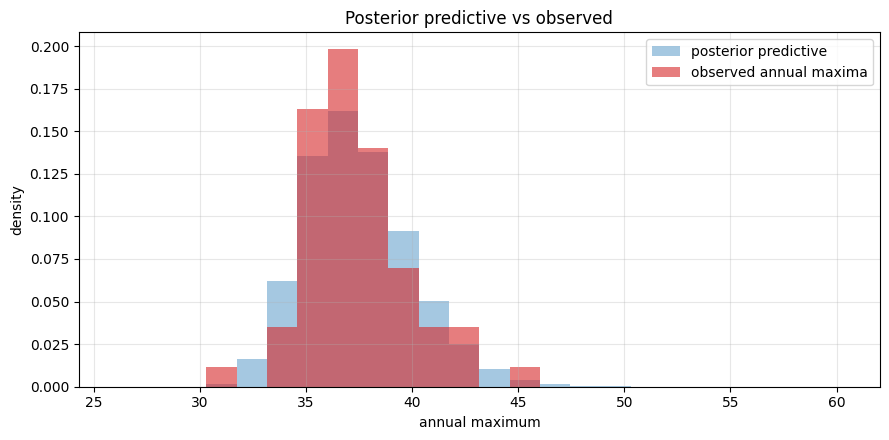

In [11]:
n_post = 500
idx = jax.random.choice(KEY, len(posterior["mu"]), shape=(n_post,), replace=False)


def sample_replicate(key, mu, sigma, xi):
    return GeneralizedExtremeValueDistribution(
        loc=mu, scale=sigma, concentration=xi
    ).sample(key, sample_shape=(n,))


keys = jax.random.split(KEY, n_post)
replicates = jax.vmap(sample_replicate)(
    keys, posterior["mu"][idx], posterior["sigma"][idx], posterior["xi"][idx]
)

fig, ax = plt.subplots(figsize=(9, 4.5))
edges = np.linspace(sorted_max.min() - 5, sorted_max.max() + 15, 25)
ax.hist(
    np.asarray(replicates).ravel(),
    bins=edges,
    density=True,
    alpha=0.4,
    color="tab:blue",
    label="posterior predictive",
)
ax.hist(
    sorted_max,
    bins=edges,
    density=True,
    alpha=0.6,
    color="tab:red",
    label="observed annual maxima",
)
ax.set_xlabel("annual maximum")
ax.set_ylabel("density")
ax.set_title("Posterior predictive vs observed")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

- **Block maxima → GEVD** is the single canonical recipe for stationary annual extremes. Three parameters $(\mu, \sigma, \xi)$, one per-block likelihood evaluation, NUTS handles the rest.
- **The shape parameter does the work.** Once you have a posterior on $\xi$ you can read off the regime: $\xi \approx 0$ here, consistent with a Gaussian parent.
- **Return levels are *posterior summaries*, not point estimates.** The credible band tells you how much the data actually pin down the long-period extreme; for short records this width is the dominant uncertainty.
- **Use a constrained $\xi$ prior.** Without it, MCMC can wander into $|\xi| > 1$ regions where moments are infinite and the posterior is weakly identified.

The next two notebooks repeat this flow on parents whose tails are *not* Gaussian, so we land in the Fréchet ($\xi > 0$) and Weibull ($\xi < 0$) regimes deliberately.